# Phase 1: Bio-Optic Sensor Calibration (Dataset 1)

A hospital has procured a new batch of low-cost, non-invasive optical biosensors designed to
measure peripheral blood oxygenation. However, the raw voltage output from the sensor needs
to be calibrated against a highly accurate (but expensive and invasive) arterial blood gas test.
While the theoretical relationship between the raw voltage and the true blood oxygen level is
linear, these low-cost sensors are inherently noisy due to ambient light interference. This dataset
serves as your pipeline’s foundational sanity check.

1. Gradient Descent vs. Closed Form: Implement Ordinary Least Squares (OLS) using
both the closed-form normal equations and vectorized batch gradient descent. Train both
on Dataset 1. Report the L2 norm of the difference between the final weight vectors
produced by both methods.

2. Primal to Dual Translation: Convert Dataset 1 into a binary classification problem
by thresholding the target variable at its median. Formulate the hard-margin SVM dual
optimization problem. Use scipy.optimize.minimize to solve for the Lagrange multi-
pliers (μ). Extract and print the exact indices of the support vectors from the training
set.

https://docs.scipy.org/doc/scipy/tutorial/index.html#user-guide

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [2]:
dataset = np.genfromtxt("../PRNN_2026_A1_data/dataset_1.csv", delimiter=",", dtype=float, skip_header=1, filling_values=np.nan)

In [3]:
dataset.shape

(5000, 2)

In [4]:
np.isnan(dataset).any()

np.False_

In [5]:
x = dataset[:, 0]
y = dataset[:, 1]

print(x.shape, y.shape)

(5000,) (5000,)


In [6]:
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)
print(x.shape, y.shape)

(5000, 1) (5000, 1)


## 1.1 Gradient Descent vs. Closed Form:

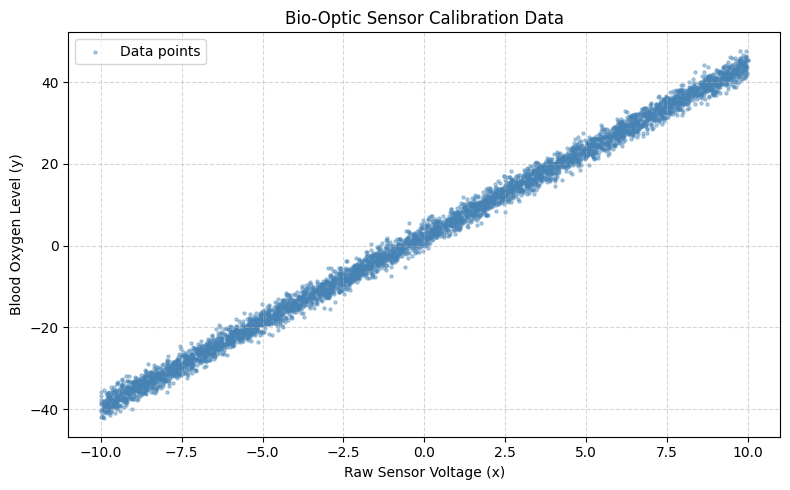

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=5, alpha=0.4, color='steelblue', label='Data points')
plt.xlabel('Raw Sensor Voltage (x)')
plt.ylabel('Blood Oxygen Level (y)')
plt.title('Bio-Optic Sensor Calibration Data')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Closed-Form Solution:

In [8]:
ones = np.ones((x.shape[0], 1))
X = np.concatenate((ones, x), axis=1)

In [9]:
X.shape, y.shape

((5000, 2), (5000, 1))

In [10]:
def solve_ols(X, Y):
    return np.linalg.inv(X.T @ X) @ X.T @ Y

In [11]:
w_cf = solve_ols(X, y)

In [12]:
w_cf

array([[2.47190022],
       [4.19290149]])

In [13]:
def solve_ols2(X, Y):
    return np.linalg.solve(X.T @ X, X.T @ Y)

w_cf = solve_ols2(X, y)

In [14]:
w_cf

array([[2.47190022],
       [4.19290149]])

### GD Solution:

In [15]:
num_data, num_dim = X.shape[0], X.shape[1]
num_data, num_dim

(5000, 2)

In [16]:
batch_size = 100
lr = 1e-3
tolerance = 1e-6

In [17]:
x_batches = np.array_split(X, num_data/batch_size)
y_batches = np.array_split(y, num_data / batch_size)
print(len(x_batches), len(y_batches))
print(x_batches[0].shape)

50 50
(100, 2)


In [18]:
w_gd = np.random.rand(num_dim, 1)
w_gd

array([[0.15825927],
       [0.48165866]])

In [19]:
losses = []
for epoch in range(1000):
    epoch_loss = ((X @ w_gd - y).T @ (X @ w_gd - y) / num_data).item()
    if epoch > 0 and abs(losses[-1] - epoch_loss) <= tolerance:
        break

    losses.append(epoch_loss)
    # print(f"Epoch {epoch} loss = {epoch_loss}")

    for x_batch,y_batch in zip(x_batches,y_batches):
        grad_loss = 2 * x_batch.T @ (x_batch @ w_gd - y_batch) / batch_size
        w_gd = w_gd - lr * grad_loss

In [21]:
w_gd

array([[2.47026767],
       [4.19971284]])

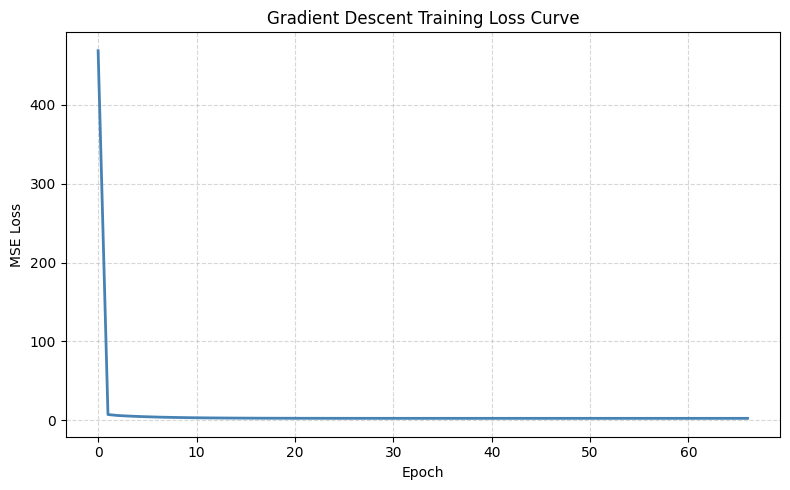

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(losses)), losses, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Training Loss Curve')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### L2 norm of difference:

In [23]:
diff = np.linalg.norm(w_cf - w_gd, ord = 2)
print(f"L2 norm of the difference between the final weight vectors produced by both methods: {diff}")

L2 norm of the difference between the final weight vectors produced by both methods: 0.007004263170872967


## 1.2 Primal to Dual Translation:

In [24]:
print(x.shape, y.shape)

(5000, 1) (5000, 1)


In [25]:
x, y = x.flatten(), y.flatten()
len_data = x.shape[0]
print(x.shape, y.shape)

(5000,) (5000,)


In [26]:
median = np.median(y)
print(f"median = {median}")

y_class = np.zeros_like(y)
y_class = (y >= median).astype(int)
y_class[y_class == 0] = -1
y_class

median = 2.3512746833404927


array([-1,  1,  1, ..., -1,  1,  1], shape=(5000,))

In [27]:
def objective_fn(mu):
    return 0.5 * np.dot(mu, np.dot(kernal_matrix, mu)) - np.sum(mu)

kernal_matrix = np.outer(y_class, y_class) * np.outer(x, x)
mu0 = np.zeros(len_data)

# ineq constraint: inf > mu_i >= 0
ineq_constr = scipy.optimize.Bounds(np.zeros(len_data), np.inf * np.ones(len_data))

# eq constraint: sum(y_i, mu_i) = 0
eq_constr = scipy.optimize.LinearConstraint(y_class.reshape(1,-1), 0, 0)

results = scipy.optimize.minimize(fun=objective_fn, x0=mu0, method='SLSQP', bounds=ineq_constr, constraints=[eq_constr], options={'disp': True})

print(f"Optimization results: {results}")

KeyboardInterrupt: 

In [28]:
tolerance = 1e-5
optimal_mu = results.x
support_vectors_mask = optimal_mu > tolerance
support_vectors = x[support_vectors_mask]
print(f"Number of support vectors: {np.sum(support_vectors_mask)}")
support_vectors_indices = np.where(support_vectors_mask)[0]

NameError: name 'results' is not defined